In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Load the dataset
# Assuming the dataset has a 'Date' column and a 'Value' column
data = pd.read_csv('data2.csv')
data = data["#Passengers"]
data.head()

,#Passengers
0,112
1,118
2,132
3,129
4,121


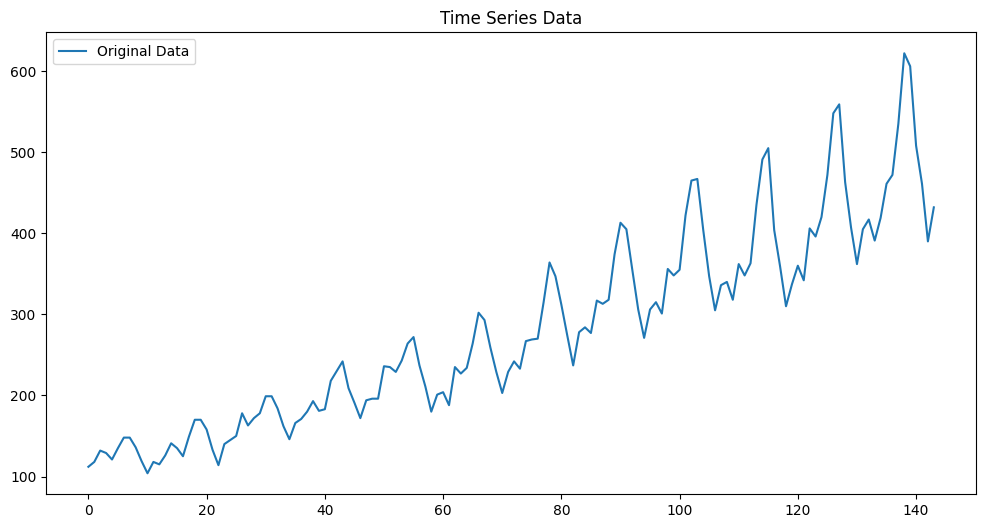

In [ ]:
# Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(data, label="Original Data")
plt.title("Time Series Data")
plt.legend()
plt.show()

In [ ]:
# Step 1: Check Stationarity
def check_stationarity(timeseries):
    result = adfuller(timeseries)
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    if result[1] <= 0.05:
        print("The series is stationary.")
    else:
        print("The series is not stationary.")

check_stationarity(data)

ADF Statistic: 0.8153688792060498
p-value: 0.991880243437641
The series is not stationary.


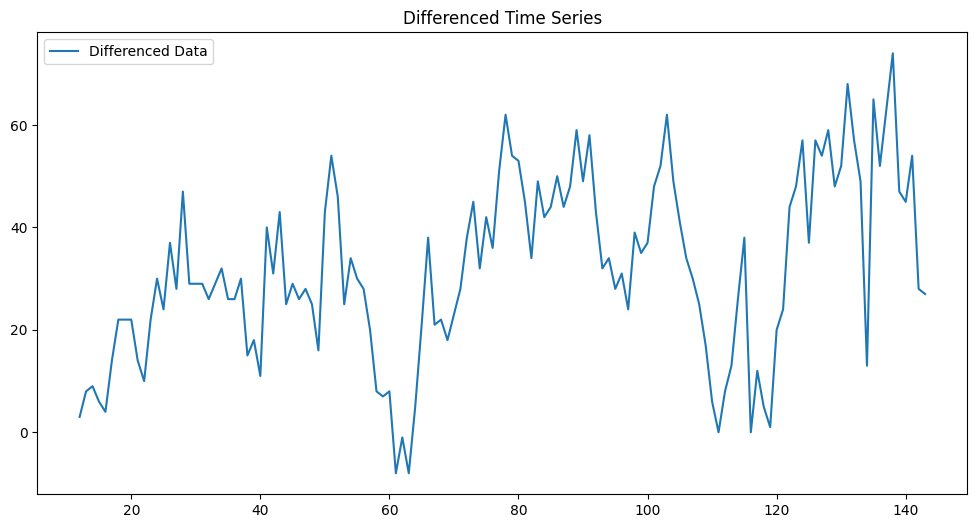

ADF Statistic: -3.383020726492481
p-value: 0.011551493085514952
The series is stationary.


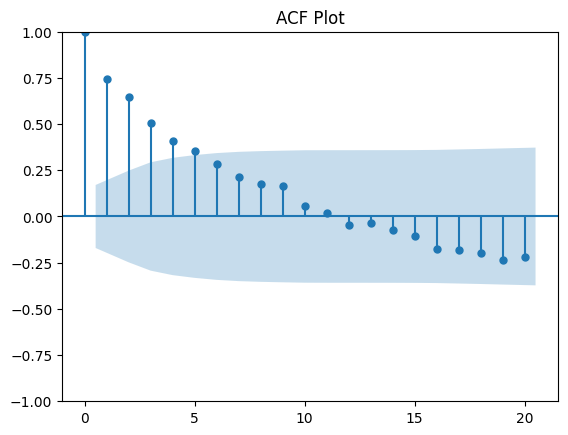

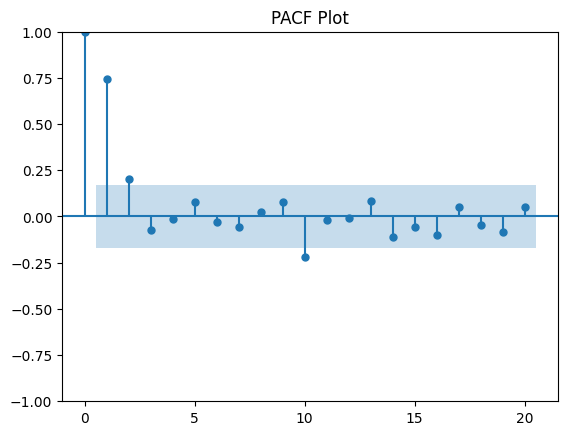

In [ ]:
# If not stationary, perform differencing
data_diff = data.diff(12).dropna()
# data_diff_diff = data_diff.diff(1).dropna()
plt.figure(figsize=(12, 6))
plt.plot(data_diff, label="Differenced Data")
plt.title("Differenced Time Series")
plt.legend()
plt.show()
check_stationarity(data_diff)

# Step 2: ACF and PACF Plots
plot_acf(data_diff, lags=20)
plt.title("ACF Plot")
plt.show()

plot_pacf(data_diff, lags=20)
plt.title("PACF Plot")
plt.show()



In [ ]:
# order = (p,d,q)

In [ ]:
# AR Model
ar_model = ARIMA(data, order=(2, 0, 0))  # Change 'p' based on PACF
ar_fit = ar_model.fit()
ar_pred = ar_fit.predict(start=0, end=len(data)-1)
ar_forecast = ar_fit.forecast(steps=12)

# MA Model
ma_model = ARIMA(data, order=(0, 0, 2))  # Change 'q' based on ACF
ma_fit = ma_model.fit()
ma_pred = ma_fit.predict(start=0, end=len(data)-1)
ma_forecast = ma_fit.forecast(steps=12)

# ARMA Model
arma_model = ARIMA(data, order=(2, 0, 2))  # Change 'p' and 'q' based on PACF and ACF
arma_fit = arma_model.fit()
arma_pred = arma_fit.predict(start=0, end=len(data)-1)
arma_forecast = arma_fit.forecast(steps=12)

# ARIMA Model
arima_model = ARIMA(data, order=(2, 1, 2))  # Adjust 'd' for differencing
arima_fit = arima_model.fit()
arima_pred = arima_fit.predict(start=1, end=len(data), typ='levels')
arima_forecast = arima_fit.forecast(steps=12)

# SARIMA Model
sarima_model = SARIMAX(data, order=(1, 1, 2), seasonal_order=(1, 1, 1, 12))
sarima_fit = sarima_model.fit()
sarima_pred = sarima_fit.predict(start=1, end=len(data))
sarima_forecast = sarima_fit.forecast(steps=12)

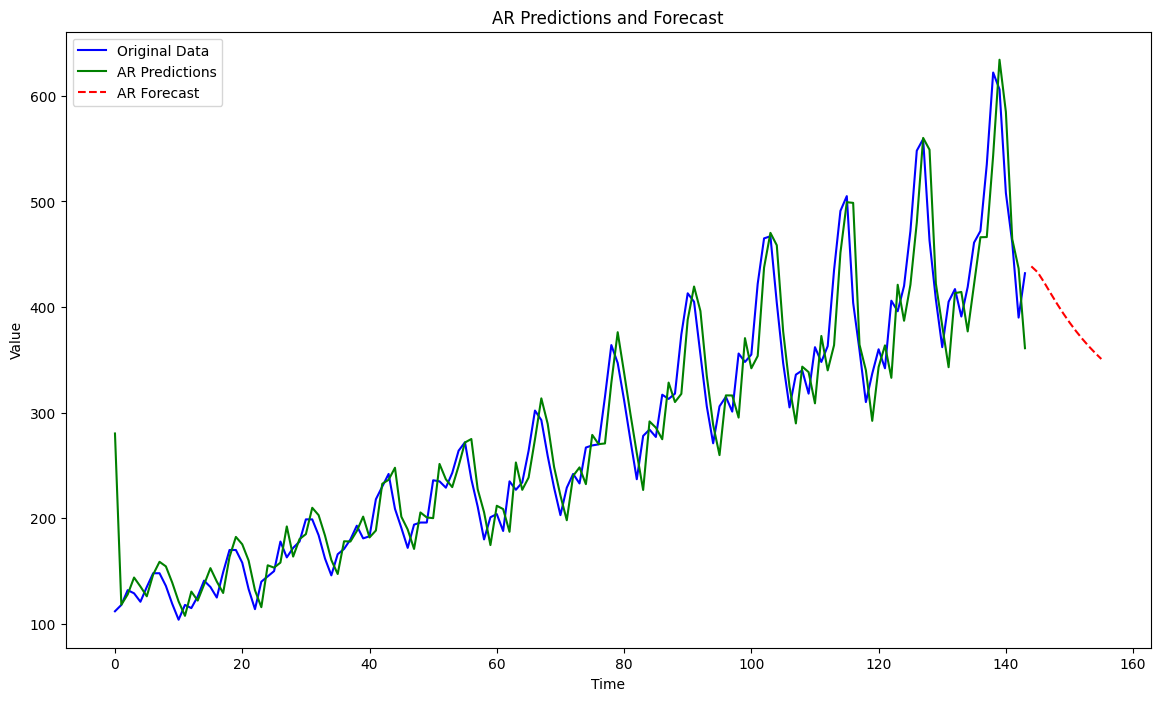

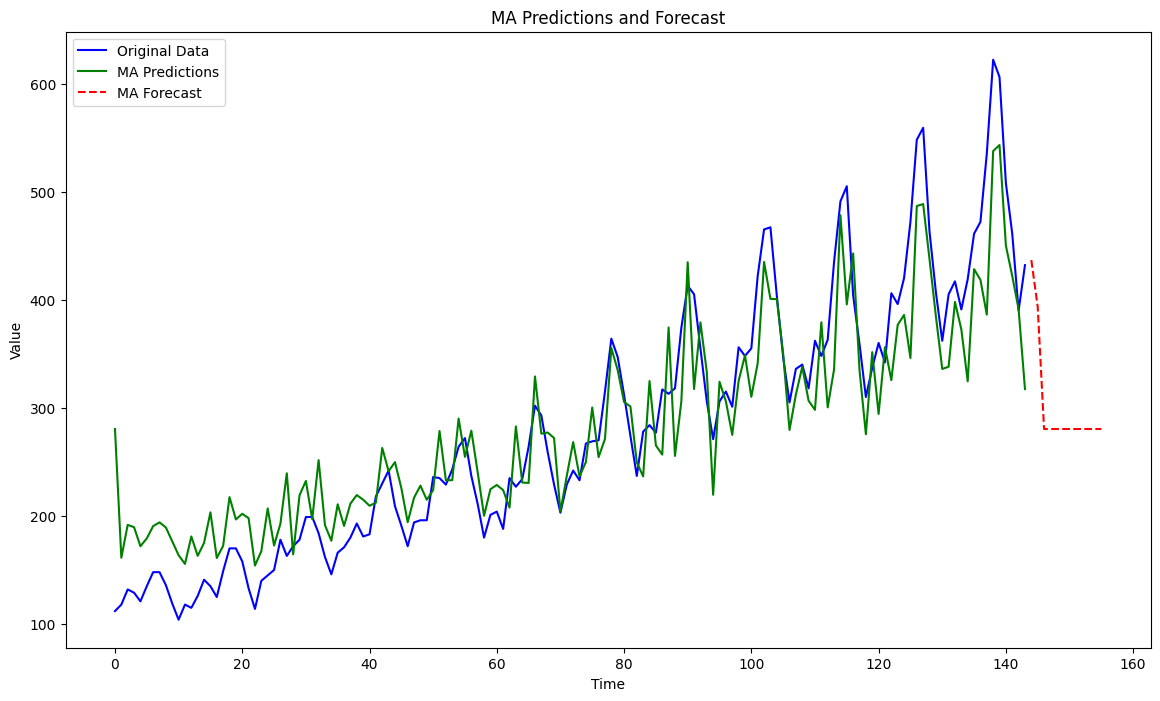

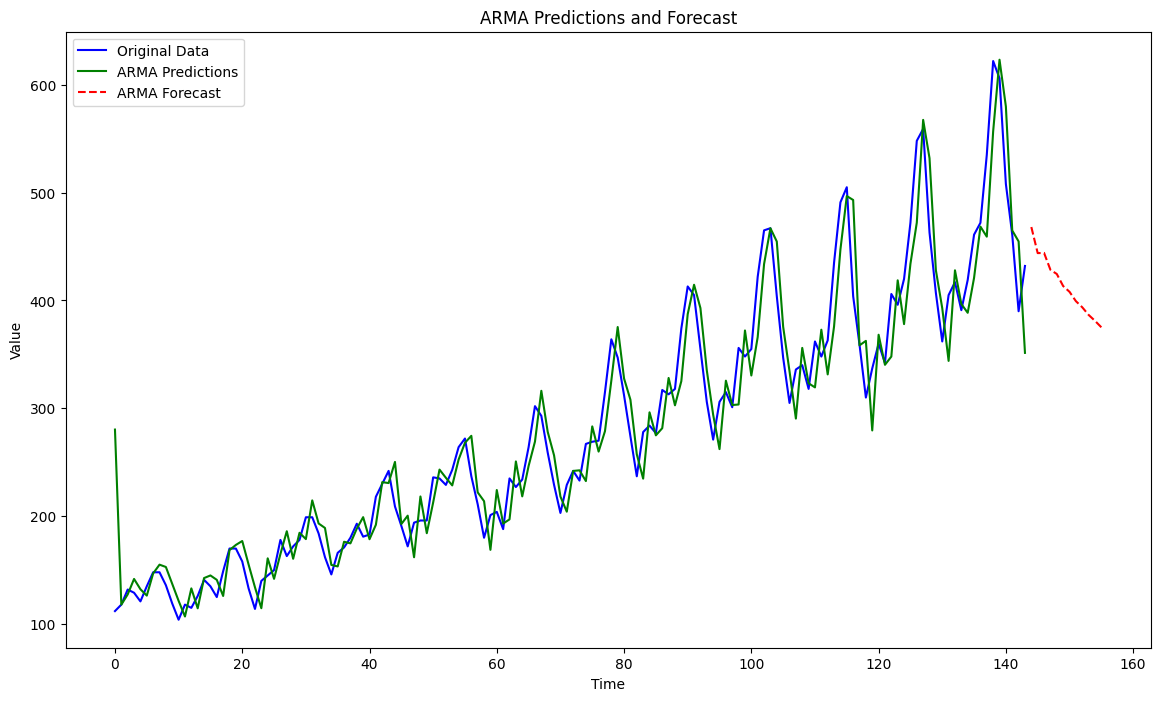

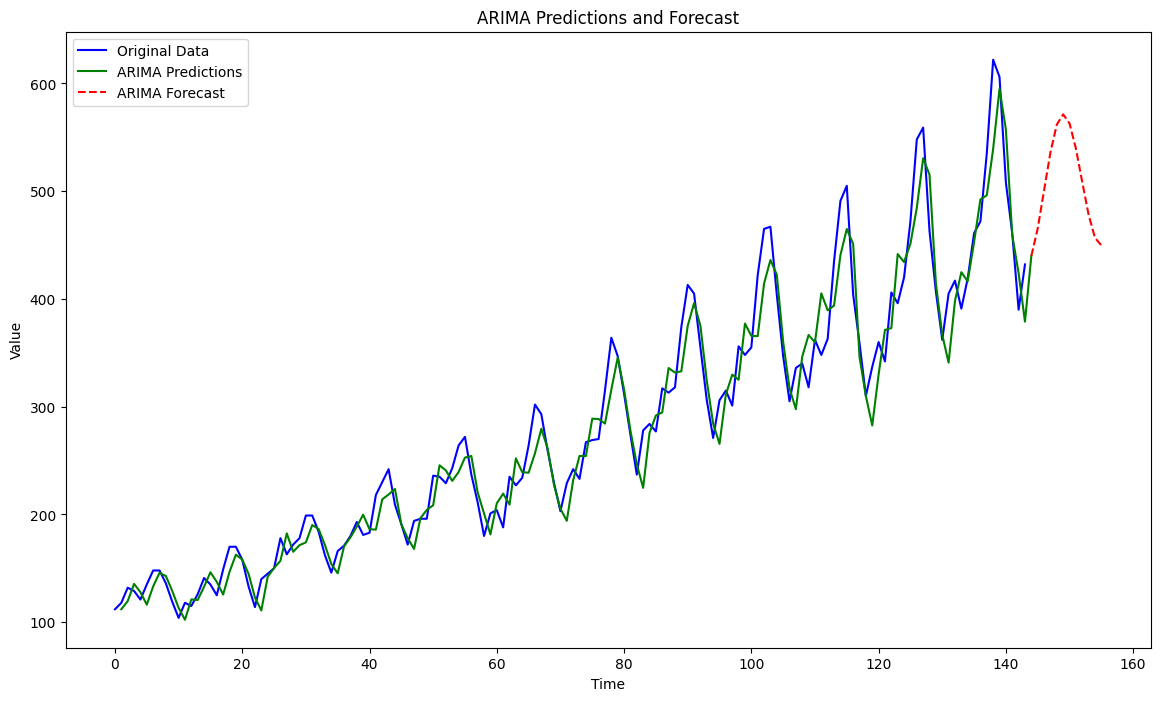

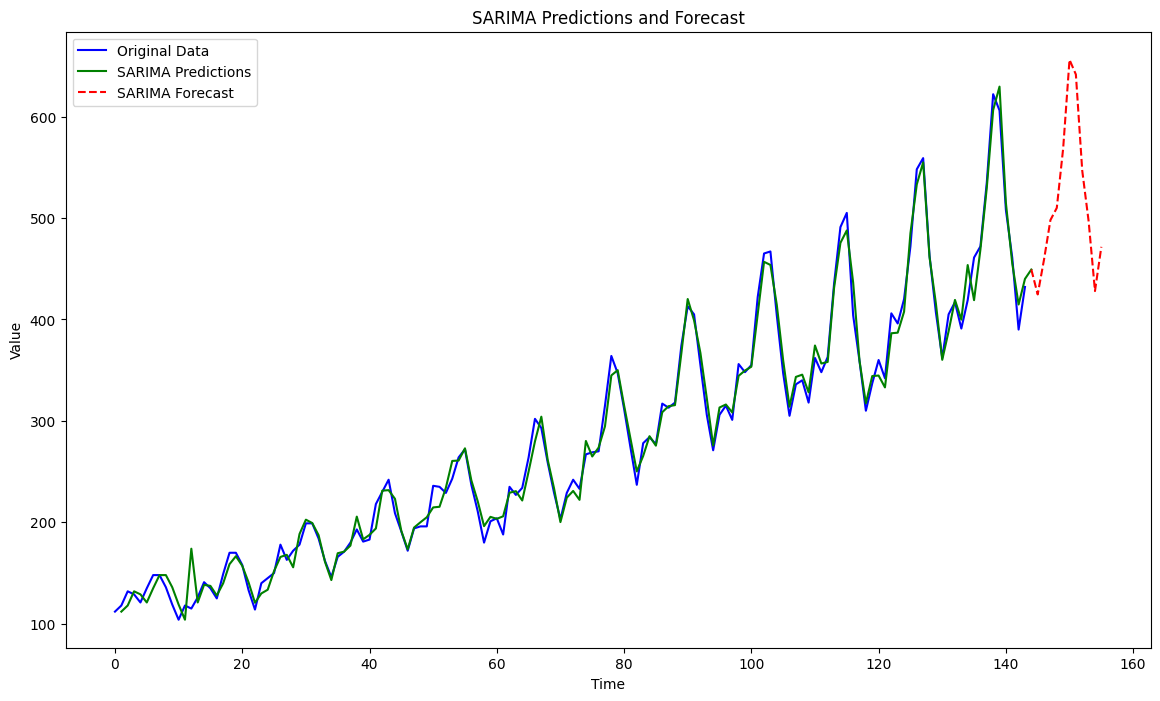

In [ ]:
# Plot Predictions and Forecasts
models = {
    "AR": (ar_pred, ar_forecast),
    "MA": (ma_pred, ma_forecast),
    "ARMA": (arma_pred, arma_forecast),
    "ARIMA": (arima_pred, arima_forecast),
    "SARIMA": (sarima_pred, sarima_forecast),
}

for model_name, (predictions, forecast) in models.items():
    plt.figure(figsize=(14, 8))
    plt.plot(data, label="Original Data", color="blue")
    plt.plot(predictions, label=f"{model_name} Predictions", color="green")
    plt.plot(
        range(len(data), len(data) + len(forecast)),
        forecast,
        label=f"{model_name} Forecast",
        color="red",
        linestyle="dashed",
    )
    plt.title(f"{model_name} Predictions and Forecast")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()
    plt.show()